# Step 6 Model Comparison and Final Model Selection

**Goal:** Pick one final model

It loads the models saved by the Step 5 notebooks, checks them against the project plan, re-scores all of them on validation and test, and applies one written-down rule to choose the winner.

**Models to compare:** Random Forest, XGBoost, Support Vector Machine, CatBoost, and Logistic Regression.

**Metrics to report:** accuracy, precision, recall, and F1-score. Those four are given their own table.

**Planned predictors:** age, sleep duration, physical activity, BMI, education, employment, income, general health, chronic diseases, and healthcare access. Step 4 checks which of these actually made it into the data, and says plainly which did not.

**Selection rule:** The target is imbalanced at roughly 10-11% positive, so accuracy alone is misleading. A model that answers "not depressed" for everyone would score about 89% accuracy while finding nobody.
    1. Primary: highest test PR-AUC. PR-AUC does not depend on a threshold and focuses on the rare positive class.
    2. Tie-break: if 2 models are within PR_AUC_TIE_MARGIN of each other, prefer the higher test recall. Missing a person who is depressed costs more than a false alarm in a screening setting.

Accuracy, precision, recall, and F1 are all reported for every model as the project asked. PR-AUC is used to *rank* them because it is the more reliable ranking metric under class imbalance. It also shows how the ranking would change if F1 were used instead, so the choice is transparent.

### Files used

**Saved models** (from `Models/`)
- `logistic_seed42.joblib`
- `random_forest_seed42.joblib`
- `svm_seed42.joblib`
- `xgboost_seed42.joblib`
- `catboost_seed42.joblib`

**Feature and target splits** (from `DataSplit/`)
- `Nhanes_SVM_Logistic_{Train,Val,Test}.csv`
- `Nhanes_XGB_Forest_{Train,Val,Test}.csv`
- `Nhanes_Cat_{Train,Val,Test}.csv`
- `Nhanes_Target_{Train,Val,Test}.csv`

### Import Libaries

In [14]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

### Configuration

In [15]:
# Folder layout - adjust BASE_DIR only if the notebook is moved out of the project root
BASE_DIR   = "."
SPLIT_DIR  = os.path.join(BASE_DIR, "DataSplit")
MODEL_DIR  = os.path.join(BASE_DIR, "Models")
FIGURE_DIR = os.path.join(BASE_DIR, "Figures")

# Create output folders if they are not there yet
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

# Same seed as every Step 5 notebook
RANDOM_STATE = 42

# The target file stem, shared by every model
TARGET_STEM = "Nhanes_Target"

# Output files
COMPARISON_CSV    = os.path.join(MODEL_DIR, "final_model_comparison.csv")
COURSE_METRICS_CSV = os.path.join(MODEL_DIR, "course_required_metrics.csv")
FEATURE_AUDIT_CSV = os.path.join(MODEL_DIR, "feature_set_audit.csv")
GOAL_CHECK_CSV    = os.path.join(MODEL_DIR, "project_goal_check.csv")
FINAL_MODEL_PATH  = os.path.join(MODEL_DIR, "final_model.joblib")
MODEL_CARD_PATH   = os.path.join(MODEL_DIR, "final_model_card.md")

# Two models this close in test PR-AUC are treated as tied, and recall decides
PR_AUC_TIE_MARGIN = 0.01

# The four metrics the project plan asked for
COURSE_METRICS = ["Accuracy", "Precision", "Recall", "F1"]

# A stable color per model so every chart in the report uses the same key
MODEL_COLORS = {
    "LogisticRegression": "#2980b9",
    "RandomForest":       "#8e44ad",
    "SVM":                "#e67e22",
    "XGBoost":            "#c0392b",
    "CatBoost":           "#27ae60",
}

In [16]:
# Columns that carry the answer - a model trained on these is invalid
LEAKING_COLUMNS = {"SEQN", "CYCLE", "PHQ9_Score", "Depression_Flag"}

# Every raw PHQ-9 item shares this prefix and would leak the target
LEAKING_PREFIXES = ("DPQ0",)

# Survey weight columns, matched by prefix because encodings name them slightly differently
SURVEY_WEIGHT_PREFIXES = ("WTMEC",)

# Redundant variables the project agreed to drop, given as base names
REDUNDANT_BASES = ["RIDRETH1", "INDFMMPI", "INDFMMPC", "ALQ142"]

# Each saved model, its file name, and the encoding it was trained on
MODEL_FILES = {
    "LogisticRegression": ("logistic_seed42.joblib",      "Nhanes_SVM_Logistic"),
    "RandomForest":       ("random_forest_seed42.joblib", "Nhanes_XGB_Forest"),
    "SVM":                ("svm_seed42.joblib",           "Nhanes_SVM_Logistic"),
    "XGBoost":            ("xgboost_seed42.joblib",       "Nhanes_XGB_Forest"),
    "CatBoost":           ("catboost_seed42.joblib",      "Nhanes_Cat"),
}

# The four models the project plan required, plus the extra baseline
REQUIRED_MODELS = ["RandomForest", "XGBoost", "SVM", "CatBoost"]
BONUS_MODELS = ["LogisticRegression"]

### Load the Feature and Target Splits

The splits are read exactly as Step 4 saved them. No columns are dropped here, because each model already knows which columns it needs. Column selection happens per model in Step 6.

In [17]:
# Cache so each CSV is read from disk only once
split_cache = {}
target_cache = {}


# Read one feature split for an encoding stem, exactly as saved
def load_split(stem, split):
    key = (stem, split)
    if key not in split_cache:
        path = os.path.join(SPLIT_DIR, f"{stem}_{split}.csv")
        if not os.path.exists(path):
            raise FileNotFoundError(f"Missing split file: {path}")
        split_cache[key] = pd.read_csv(path, low_memory=False)
    return split_cache[key]


# Return the target vector for one split as a flat array
def load_target(split):
    if split not in target_cache:
        path = os.path.join(SPLIT_DIR, f"{TARGET_STEM}_{split}.csv")
        if not os.path.exists(path):
            raise FileNotFoundError(f"Missing target file: {path}")
        target_cache[split] = pd.read_csv(path)["Depression_Flag"].to_numpy()
    return target_cache[split]

In [18]:
# Confirm the target splits load and the class balance matches Step 5
split_summary = []
for split in ["Train", "Val", "Test"]:
    y = load_target(split)
    split_summary.append({
        "Split": split,
        "Rows": len(y),
        "Positives": int(y.sum()),
        "Positive_Rate": round(float(y.mean()), 4),
    })

split_summary = pd.DataFrame(split_summary)
display(split_summary)

# The three splits must have a similar positive rate or the comparison is not valid
rate_spread = split_summary["Positive_Rate"].max() - split_summary["Positive_Rate"].min()
print(f"Positive rate spread across splits: {rate_spread:.4f}")

if rate_spread > 0.03:
    print("WARNING  The splits are not balanced the same way. Check the Step 4 stratification.")
else:
    print("The splits carry a similar positive rate, so stratification held.")

,Split,Rows,Positives,Positive_Rate
0,Train,9611,1020,0.1061
1,Val,2060,235,0.1141
2,Test,2060,235,0.1141


Positive rate spread across splits: 0.0080
The splits carry a similar positive rate, so stratification held.


### Load the Saved Models

Every Step 5 notebook saved a small bundle: the fitted estimator, its tuned threshold, and the exact column order it was trained on. Each bundle is stored here as a plain dictionary.

In [19]:
# Turn one saved joblib bundle into a plain dictionary this notebook can use
def build_model_entry(name, bundle, stem):
    if "model" not in bundle or "columns" not in bundle:
        raise KeyError(f"{name}: bundle must have 'model' and 'columns' keys")

    return {
        "name": name,
        "model": bundle["model"],
        "columns": list(bundle["columns"]),
        "categorical": list(bundle.get("cat_features", [])),
        "params": bundle.get("params", bundle.get("C", {})),
        "stem": stem,
        "color": MODEL_COLORS.get(name, "#7f8c8d"),

        # Fall back to 0.50 if a Step 5 notebook forgot to save its tuned threshold
        "threshold": float(bundle.get("threshold", 0.50)),
    }


# Load every model file that exists, and record why any model could not be loaded
def load_saved_models():
    entries = []
    skipped = []

    for name, (file_name, stem) in MODEL_FILES.items():
        path = os.path.join(MODEL_DIR, file_name)

        # The Step 5 notebook for this model has not been run, or saved to the wrong folder
        if not os.path.exists(path):
            skipped.append((name, f"file not found at {path}"))
            continue

        try:
            bundle = joblib.load(path)

        # The file is there, but the library that created the model is not installed here
        except ModuleNotFoundError as error:
            skipped.append((name, f"library '{error.name}' is not installed in this kernel"))
            continue

        entries.append(build_model_entry(name, bundle, stem))

    if not entries:
        raise FileNotFoundError(
            f"No models could be loaded from {MODEL_DIR} - "
            f"run the Step 5 notebooks and install any missing libraries first"
        )

    return entries, skipped

In [20]:
# Load whatever Step 5 produced
models, skipped_models = load_saved_models()

print(f"Loaded {len(models)} model(s):")
for entry in models:
    print(f"  {entry['name']:<20} encoding={entry['stem']:<22} "
          f"features={len(entry['columns']):>3}  threshold={entry['threshold']:.4f}")

for name, reason in skipped_models:
    print(f"\nWARNING  {name} was skipped - {reason}")

    if "not installed" in reason:
        library = reason.split("'")[1]
        print(f"         Install it into this kernel, then restart and re-run:")
        print(f"             %pip install {library}")
    else:
        print(f'         Check that its Step 5 notebook uses BASE_DIR = "." and re-run it.')

Loaded 5 model(s):
  LogisticRegression   encoding=Nhanes_SVM_Logistic    features= 54  threshold=0.6275
  RandomForest         encoding=Nhanes_XGB_Forest      features= 54  threshold=0.5338
  SVM                  encoding=Nhanes_SVM_Logistic    features= 54  threshold=0.1706
  XGBoost              encoding=Nhanes_XGB_Forest      features= 54  threshold=0.5808
  CatBoost             encoding=Nhanes_Cat             features= 18  threshold=0.5763


### Check the Work Against the Project Plan


1. **Models.** Are all four required models present?
2. **Predictors.** Which of the planned variables actually reached the model, and which did not?
3. **Testing protocol.** Was the test set held back and the threshold tuned on validation only?

#### 1 Are the required models all here?

In [21]:
# Compare the models that loaded against the four the project plan required
loaded_names = [entry["name"] for entry in models]

model_check = pd.DataFrame([
    {
        "Model": name,
        "Role": "Required by plan" if name in REQUIRED_MODELS else "Extra baseline",
        "Status": "Present" if name in loaded_names else "MISSING",
    }
    for name in REQUIRED_MODELS + BONUS_MODELS
])

display(model_check)

missing_required = [
    name for name in REQUIRED_MODELS if name not in loaded_names
]

if missing_required:
    print(f"WARNING  These required models are missing: {', '.join(missing_required)}")
    print(f"         The comparison is incomplete until their Step 5 notebooks are run.")
else:
    print("All four required models are present.")

,Model,Role,Status
0,RandomForest,Required by plan,Present
1,XGBoost,Required by plan,Present
2,SVM,Required by plan,Present
3,CatBoost,Required by plan,Present
4,LogisticRegression,Extra baseline,Present


All four required models are present.


####  Which planned predictors actually made it in?

Each planned concept is matched against the variable codes that appear in the models. The match is done by NHANES prefix, so the notebook reports what is really in the data rather than what was hoped for.

In [22]:
# Map each concept from the project plan to the NHANES prefixes that would carry it
PLANNED_PREDICTORS = {
    "Age":                ["RIDAGEYR"],
    "Sleep duration":     ["SLD012", "SLD013", "SLQ"],
    "Physical activity":  ["PAD", "PAQ"],
    "BMI":                ["BMX", "BMI"],
    "Education":          ["DMDEDUC", "DMDHREDZ"],
    "Employment":         ["OCD", "OCQ"],
    "Income":             ["INDFMPIR", "INDFMMP", "INDHHIN"],
    "General health":     ["HSD010"],
    "Chronic diseases":   ["MCQ", "DIQ", "BPQ"],
    "Healthcare access":  ["HUQ"],
}


# Return every column name used by any loaded model
def all_model_columns(entries):
    columns = set()
    for entry in entries:
        columns.update(entry["columns"])
    return sorted(columns)


# Find which columns carry a given concept, matching on NHANES prefix
def columns_for_concept(prefixes, columns):
    return sorted(
        column for column in columns
        if any(column.upper().startswith(prefix.upper()) for prefix in prefixes)
    )

In [23]:
# Check every planned concept against the columns the models really used
model_columns = all_model_columns(models)

goal_rows = []
for concept, prefixes in PLANNED_PREDICTORS.items():
    matches = columns_for_concept(prefixes, model_columns)
    goal_rows.append({
        "Planned_Predictor": concept,
        "Status": "In model" if matches else "NOT IN DATA",
        "Columns_Found": ", ".join(matches[:4]) + (" ..." if len(matches) > 4 else "") if matches else "-",
    })

goal_check = pd.DataFrame(goal_rows)
display(goal_check)

# Save it so the report can cite the same table
goal_check.to_csv(GOAL_CHECK_CSV, index=False)

covered = (goal_check["Status"] == "In model").sum()
print(f"{covered} of {len(goal_check)} planned predictors are in the model.")

not_in_data = list(goal_check.loc[goal_check["Status"] == "NOT IN DATA", "Planned_Predictor"])
if not_in_data:
    print()
    print(f"NOT IN THE DATA: {', '.join(not_in_data)}")
    print("These were named in the project plan but never made it into the modeling files.")
    print("Say so in the report's limitations section rather than leaving the reader to assume")
    print("they were included.")

,Planned_Predictor,Status,Columns_Found
0,Age,In model,RIDAGEYR
1,Sleep duration,In model,"SLD012, SLD013"
2,Physical activity,In model,PAD680
3,BMI,NOT IN DATA,-
4,Education,In model,"DMDEDUC2, DMDEDUC2_-1.0, DMDEDUC2_1.0, DMDEDUC..."
5,Employment,NOT IN DATA,-
6,Income,In model,INDFMPIR
7,General health,NOT IN DATA,-
8,Chronic diseases,NOT IN DATA,-
9,Healthcare access,NOT IN DATA,-


5 of 10 planned predictors are in the model.

NOT IN THE DATA: BMI, Employment, General health, Chronic diseases, Healthcare access
These were named in the project plan but never made it into the modeling files.
Say so in the report's limitations section rather than leaving the reader to assume
they were included.


In [24]:
# List the predictors the models use that were not named in the plan
planned_columns = set()
for prefixes in PLANNED_PREDICTORS.values():
    planned_columns.update(columns_for_concept(prefixes, model_columns))

unplanned = sorted(set(model_columns) - planned_columns)

# Reduce one-hot dummies back to their base variable so the list stays readable
unplanned_bases = sorted({column.split("_")[0] for column in unplanned})

print("Variables in the models that the plan did not name:")
print(f"  {', '.join(unplanned_bases)}")
print()
print("These are mostly alcohol (ALQ), smoking (SMQ), and demographic controls.")
print("They are reasonable additions, but the report should describe the feature set")
print("that was actually used, not the one that was originally proposed.")

Variables in the models that the plan did not name:
  ALQ111, ALQ121, ALQ130, ALQ151, ALQ170, DMDBORN4, DMDMARTZ, HSQ590, RIAGENDR, RIDEXMON, RIDRETH3, SMQ020

These are mostly alcohol (ALQ), smoking (SMQ), and demographic controls.
They are reasonable additions, but the report should describe the feature set
that was actually used, not the one that was originally proposed.


#### 3 Was the testing protocol followed?

In [25]:
# Confirm the rules that keep the test estimate honest
protocol_checks = []

# The three splits must not overlap, which Step 4 guaranteed by splitting once
protocol_checks.append({
    "Check": "Train, validation and test come from Step 4 and are not re-split here",
    "Result": "PASS",
    "Detail": f"{len(load_target('Train'))} / {len(load_target('Val'))} / {len(load_target('Test'))} rows",
})

# Every model must carry a threshold that was chosen on validation, not on test
default_threshold_models = [
    entry["name"] for entry in models if abs(entry["threshold"] - 0.50) < 1e-9
]
protocol_checks.append({
    "Check": "Every model has a threshold tuned on validation",
    "Result": "PASS" if not default_threshold_models else "REVIEW",
    "Detail": "all tuned" if not default_threshold_models
              else f"still at default 0.50: {', '.join(default_threshold_models)}",
})

# The class balance must be similar across splits or the test estimate is biased
protocol_checks.append({
    "Check": "Positive rate is similar across all three splits",
    "Result": "PASS" if rate_spread <= 0.03 else "REVIEW",
    "Detail": f"spread {rate_spread:.4f}",
})

# The seed must match so anyone can reproduce the run
protocol_checks.append({
    "Check": "One random seed shared by every notebook",
    "Result": "PASS",
    "Detail": f"RANDOM_STATE = {RANDOM_STATE}",
})

display(pd.DataFrame(protocol_checks))

,Check,Result,Detail
0,"Train, validation and test come from Step 4 an...",PASS,9611 / 2060 / 2060 rows
1,Every model has a threshold tuned on validation,PASS,all tuned
2,Positive rate is similar across all three splits,PASS,spread 0.0080
3,One random seed shared by every notebook,PASS,RANDOM_STATE = 42


### Feature Set Audit

A fair comparison means every model saw the same information. This step checks that.

For each encoding it works out the project standard column list, then compares each model's actual trained columns against it.

- **Leaking columns** stop the notebook. There is no safe way to continue.
- **Extra non-standard columns** produce a warning. The model still gets compared, but the report should mention it had more to work with.

In [26]:
# Find any column that carries the answer - these make a model invalid
def find_leaking_columns(columns):
    return sorted(
        column for column in columns
        if column in LEAKING_COLUMNS or column.startswith(LEAKING_PREFIXES)
    )


# Decide whether one column is a survey weight or a redundant variable
def is_non_standard(column):
    if column.upper().startswith(SURVEY_WEIGHT_PREFIXES):
        return True

    # Match both the plain name and its one-hot dummies, for example RIDRETH1 and RIDRETH1_3.0
    return any(
        column == base or column.startswith(base + "_")
        for base in REDUNDANT_BASES
    )


# Find survey design or redundant columns the project agreed to drop
def find_non_standard_columns(columns):
    return sorted(column for column in columns if is_non_standard(column))


# Work out the column list this encoding should have used, following the Step 5 rules
def project_standard_columns(stem):
    raw_columns = list(load_split(stem, "Train").columns)

    return [
        column for column in raw_columns
        if not is_non_standard(column)
        and column not in LEAKING_COLUMNS
        and not column.startswith(LEAKING_PREFIXES)
    ]

In [27]:
# Compare every model's trained columns against the project standard for its encoding
def audit_feature_sets(entries):
    rows = []

    for entry in entries:
        standard = project_standard_columns(entry["stem"])
        trained = entry["columns"]

        leaking = find_leaking_columns(trained)
        non_standard = find_non_standard_columns(trained)
        unused = sorted(set(standard) - set(trained))

        rows.append({
            "Model": entry["name"],
            "Encoding": entry["stem"],
            "Features_Used": len(trained),
            "Project_Standard": len(standard),
            "Leaking": ", ".join(leaking) if leaking else "-",
            "Extra_Non_Standard": ", ".join(non_standard) if non_standard else "-",
            "Standard_Not_Used": ", ".join(unused) if unused else "-",
        })

    return pd.DataFrame(rows)

In [28]:
# Run the audit and show it
feature_audit = audit_feature_sets(models)
display(feature_audit)

# A leaking column means the model learned the answer - there is no way to continue
leaking_models = feature_audit[feature_audit["Leaking"] != "-"]
if not leaking_models.empty:
    raise ValueError(
        f"These models were trained on target-leaking columns and cannot be used: "
        f"{list(leaking_models['Model'])}"
    )

print("No target leakage found in any model.")

,Model,Encoding,Features_Used,Project_Standard,Leaking,Extra_Non_Standard,Standard_Not_Used
0,LogisticRegression,Nhanes_SVM_Logistic,54,54,-,-,-
1,RandomForest,Nhanes_XGB_Forest,54,54,-,-,-
2,SVM,Nhanes_SVM_Logistic,54,54,-,-,-
3,XGBoost,Nhanes_XGB_Forest,54,54,-,-,-
4,CatBoost,Nhanes_Cat,18,18,-,-,-


No target leakage found in any model.


In [29]:
# Warn about any model that used columns the others dropped
unfair_models = feature_audit[feature_audit["Extra_Non_Standard"] != "-"]

if unfair_models.empty:
    print("Every model used the project standard feature set. The comparison is like for like.")
else:
    print("WARNING  These models were trained on columns the other models dropped:")
    print()
    for _, row in unfair_models.iterrows():
        print(f"  {row['Model']}  ->  {row['Extra_Non_Standard']}")
    print()
    print("  They still appear in the comparison, but they had information the others did not.")
    print("  Say so in the report, or re-run their Step 5 notebook with the same column")
    print("  clean-up the other notebooks use, then re-run this notebook.")

# Save the audit so the report can cite it
feature_audit.to_csv(FEATURE_AUDIT_CSV, index=False)
print()
print(f"Saved feature audit: {FEATURE_AUDIT_CSV}")

Every model used the project standard feature set. The comparison is like for like.

Saved feature audit: .\Models\feature_set_audit.csv


### Score Every Model

One scoring function is used for every model, so the numbers are directly comparable. Each model is scored twice per split: once at the default 0.50 threshold, and once at the threshold it tuned on validation.

In [30]:
# Select the exact columns this model was trained on, in the trained order
def prepare_features(frame, columns, categorical):
    missing = [column for column in columns if column not in frame.columns]
    if missing:
        raise ValueError(
            f"Split is missing {len(missing)} trained columns, first few: {missing[:5]}"
        )

    prepared = frame[columns].copy()

    # CatBoost was trained on string categories, so cast them back before scoring
    for column in categorical:
        prepared[column] = prepared[column].astype(str)

    return prepared


# Return the predicted probability of the positive class for one model and split
def predict_positive_proba(entry, split):
    frame = load_split(entry["stem"], split)
    prepared = prepare_features(frame, entry["columns"], entry["categorical"])
    return entry["model"].predict_proba(prepared)[:, 1]


# Turn one set of predicted probabilities into a full row of metrics
def score_predictions(y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)
    return {
        "Accuracy":  accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall":    recall_score(y_true, pred, zero_division=0),
        "F1":        f1_score(y_true, pred, zero_division=0),
        "PR_AUC":    average_precision_score(y_true, proba),
        "ROC_AUC":   roc_auc_score(y_true, proba),
        "Threshold": threshold,
    }

In [31]:
# Score every model on every split, keeping the probabilities for the curve plots
def score_all_models(entries, splits=("Val", "Test")):
    rows = []
    probabilities = {}

    for entry in entries:
        for split in splits:
            y_true = load_target(split)
            proba = predict_positive_proba(entry, split)

            # Save the probabilities so the charts do not need a second pass
            probabilities[(entry["name"], split)] = (y_true, proba)

            rows.append({
                "Model": entry["name"], "Split": split, "Threshold_Type": "Default 0.50",
                **score_predictions(y_true, proba, 0.50),
            })
            rows.append({
                "Model": entry["name"], "Split": split, "Threshold_Type": "Tuned",
                **score_predictions(y_true, proba, entry["threshold"]),
            })

    column_order = ["Model", "Split", "Threshold_Type",
                    "Accuracy", "Precision", "Recall", "F1",
                    "PR_AUC", "ROC_AUC", "Threshold"]

    return pd.DataFrame(rows)[column_order], probabilities

In [32]:
# Score everything that loaded
results, probabilities = score_all_models(models)

print(f"Scored {results['Model'].nunique()} models "
      f"x {results['Split'].nunique()} splits "
      f"x 2 thresholds = {len(results)} rows")

Scored 5 models x 2 splits x 2 thresholds = 20 rows


### Model Comparison

#### 1.The four metrics the project asked for

Test set, at each model's tuned threshold. This is the table the report should lead with.

In [33]:
# Every model on the held-out test set, showing the four required metrics
test_tuned = (
    results
    .query("Split == 'Test' and Threshold_Type == 'Tuned'")
    .sort_values("PR_AUC", ascending=False)
    .reset_index(drop=True)
)

# The plan asked for accuracy, precision, recall and F1
course_table = test_tuned.set_index("Model")[COURSE_METRICS].round(4)
display(course_table)

# Save it separately so the report can cite exactly these four numbers
course_table.to_csv(COURSE_METRICS_CSV)
print(f"Saved: {COURSE_METRICS_CSV}")

,Accuracy,Precision,Recall,F1
Model,,,,
CatBoost,0.7573,0.2257,0.4638,0.3036
XGBoost,0.7723,0.2365,0.4468,0.3093
SVM,0.7864,0.2577,0.4638,0.3313
LogisticRegression,0.7820,0.2415,0.4255,0.3082
RandomForest,0.7932,0.2232,0.3277,0.2655


Saved: .\Models\course_required_metrics.csv


Accuracy looks highest for the models that flag the fewest people, which is exactly the trap class imbalance sets. Recall is the share of depressed people the model actually finds. Precision is how often a flag is correct. F1 balances the two. For a screening tool, recall usually matters most.

#### 2. Does the ranking depend on which metric you use?

The selection rule ranks by PR-AUC. This table shows how the order would change under F1 or recall, so the report can state the choice openly instead of hiding it.

In [34]:
# Rank every model under three different metrics and compare the orders
ranking = test_tuned.set_index("Model")[["PR_AUC", "F1", "Recall"]].copy()

for metric in ["PR_AUC", "F1", "Recall"]:
    ranking[f"Rank_by_{metric}"] = ranking[metric].rank(ascending=False).astype(int)

display(ranking.round(4))

# Say plainly whether the metric choice changes the winner
winners = {
    metric: ranking[metric].idxmax()
    for metric in ["PR_AUC", "F1", "Recall"]
}

print("Top model under each metric:")
for metric, winner in winners.items():
    print(f"  {metric:<8} -> {winner}")

if len(set(winners.values())) == 1:
    print()
    print("All three metrics agree on the same model, so the ranking is robust.")
else:
    print()
    print("The metrics disagree. The report should name the metric used to decide")
    print("and explain why, rather than quietly picking the most flattering one.")

,PR_AUC,F1,Recall,Rank_by_PR_AUC,Rank_by_F1,Rank_by_Recall
Model,,,,,,
CatBoost,0.2723,0.3036,0.4638,1,4,1
XGBoost,0.2716,0.3093,0.4468,2,2,3
SVM,0.2580,0.3313,0.4638,3,1,1
LogisticRegression,0.2444,0.3082,0.4255,4,3,4
RandomForest,0.2327,0.2655,0.3277,5,5,5


Top model under each metric:
  PR_AUC   -> CatBoost
  F1       -> SVM
  Recall   -> CatBoost

The metrics disagree. The report should name the metric used to decide
and explain why, rather than quietly picking the most flattering one.


#### 3. Full test table with supporting metrics

In [35]:
# The complete test picture, including the threshold-free metrics
display(test_tuned.drop(columns="Threshold_Type").round(4))

,Model,Split,Accuracy,Precision,Recall,F1,PR_AUC,ROC_AUC,Threshold
0,CatBoost,Test,0.7573,0.2257,0.4638,0.3036,0.2723,0.6761,0.5763
1,XGBoost,Test,0.7723,0.2365,0.4468,0.3093,0.2716,0.6813,0.5808
2,SVM,Test,0.7864,0.2577,0.4638,0.3313,0.2580,0.6795,0.1706
3,LogisticRegression,Test,0.7820,0.2415,0.4255,0.3082,0.2444,0.6781,0.6275
4,RandomForest,Test,0.7932,0.2232,0.3277,0.2655,0.2327,0.6736,0.5338


#### 4. Validation set

Validation is where the hyperparameters and thresholds were chosen. A model that looks much stronger here than on test is a sign of overfitting to the validation set during tuning.

In [36]:
# Validation performance at each model's tuned threshold
val_tuned = (
    results
    .query("Split == 'Val' and Threshold_Type == 'Tuned'")
    .sort_values("PR_AUC", ascending=False)
    .reset_index(drop=True)
)

display(val_tuned.drop(columns="Threshold_Type").round(4))

,Model,Split,Accuracy,Precision,Recall,F1,PR_AUC,ROC_AUC,Threshold
0,SVM,Val,0.8073,0.3043,0.5362,0.3883,0.2749,0.7544,0.1706
1,CatBoost,Val,0.7840,0.2603,0.4851,0.3388,0.2497,0.7253,0.5763
2,RandomForest,Val,0.8160,0.2870,0.4128,0.3386,0.2437,0.7153,0.5338
3,XGBoost,Val,0.7913,0.2569,0.4383,0.3239,0.2383,0.7087,0.5808
4,LogisticRegression,Val,0.7937,0.2564,0.4255,0.3200,0.2342,0.7041,0.6275


#### 5. Validation to test gap

A large drop from validation to test means the tuning choices did not carry over to unseen data.

In [37]:
# Compare PR-AUC on validation against PR-AUC on test for each model
generalization = (
    results
    .query("Threshold_Type == 'Tuned'")
    .pivot(index="Model", columns="Split", values="PR_AUC")
    .rename(columns={"Val": "Val_PR_AUC", "Test": "Test_PR_AUC"})
)

generalization["Gap"] = generalization["Val_PR_AUC"] - generalization["Test_PR_AUC"]
generalization = generalization.sort_values("Test_PR_AUC", ascending=False)

display(generalization.round(4))

Split,Test_PR_AUC,Val_PR_AUC,Gap
Model,,,
CatBoost,0.2723,0.2497,-0.0226
XGBoost,0.2716,0.2383,-0.0332
SVM,0.2580,0.2749,0.0169
LogisticRegression,0.2444,0.2342,-0.0102
RandomForest,0.2327,0.2437,0.0110


#### 6. What the threshold is buying

PR-AUC and ROC-AUC do not depend on a cut-off, so they are identical either way. Only accuracy, precision, recall, and F1 move.

In [38]:
# Show how the tuned threshold shifts the cut-off dependent metrics on test
threshold_effect = (
    results
    .query("Split == 'Test'")
    .pivot(index="Model", columns="Threshold_Type", values=["Recall", "Precision", "F1"])
    .round(4)
)

display(threshold_effect)

Recall            Precision                   F1        
Threshold_Type     Default 0.50   Tuned Default 0.50   Tuned Default 0.50   Tuned
Model                                                                            
CatBoost                 0.6043  0.4638       0.1873  0.2257       0.2860  0.3036
LogisticRegression       0.6000  0.4255       0.1808  0.2415       0.2778  0.3082
RandomForest             0.4426  0.3277       0.2281  0.2232       0.3010  0.2655
SVM                      0.0638  0.4638       0.5556  0.2577       0.1145  0.3313
XGBoost                  0.5617  0.4468       0.1886  0.2365       0.2824  0.3093

### Comparison Charts

##### Precision-Recall curves on the test set

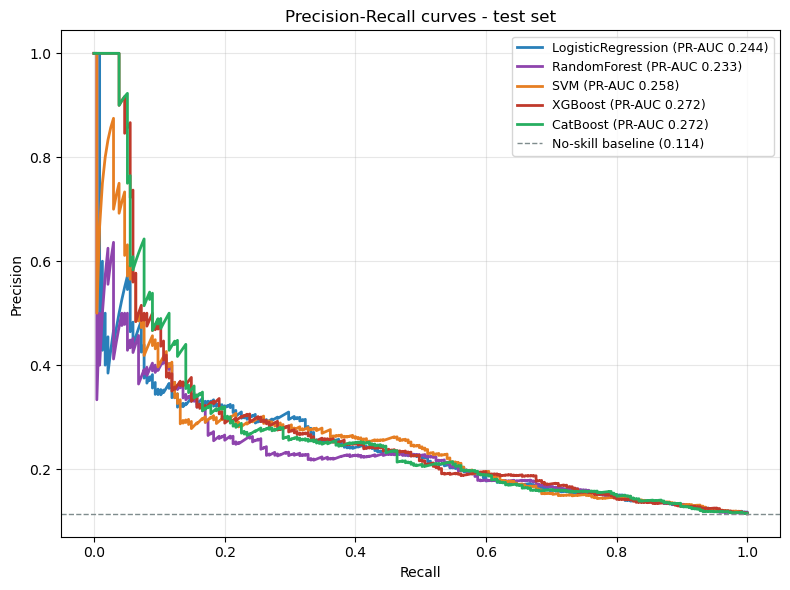

In [39]:
# Overlay the PR curve for every model, since PR-AUC is the primary metric
fig, ax = plt.subplots(figsize=(8, 6))

for entry in models:
    y_true, proba = probabilities[(entry["name"], "Test")]
    precision, recall, _ = precision_recall_curve(y_true, proba)
    pr_auc = average_precision_score(y_true, proba)
    ax.plot(recall, precision, color=entry["color"], linewidth=2,
            label=f"{entry['name']} (PR-AUC {pr_auc:.3f})")

# The baseline is the positive rate: what a model that guesses at random would reach
positive_rate = load_target("Test").mean()
ax.axhline(positive_rate, color="#7f8c8d", linestyle="--", linewidth=1,
           label=f"No-skill baseline ({positive_rate:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall curves - test set")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "6_1_pr_curves_test.png"), dpi=150)
plt.show()

The dashed line is what a model with no skill would achieve. The gap between each curve and that line is the real signal the model found.

##### ROC curves on the test set

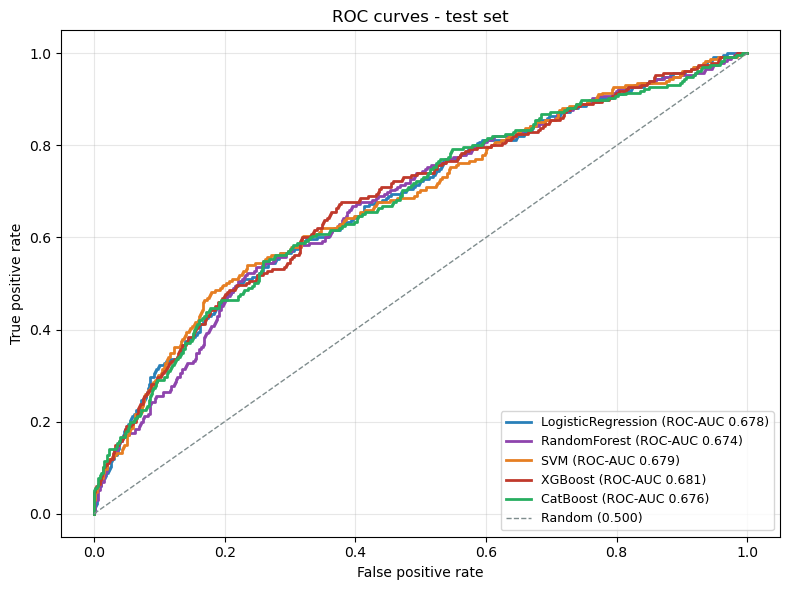

In [40]:
# Overlay the ROC curve for every model
fig, ax = plt.subplots(figsize=(8, 6))

for entry in models:
    y_true, proba = probabilities[(entry["name"], "Test")]
    fpr, tpr, _ = roc_curve(y_true, proba)
    auc = roc_auc_score(y_true, proba)
    ax.plot(fpr, tpr, color=entry["color"], linewidth=2,
            label=f"{entry['name']} (ROC-AUC {auc:.3f})")

# The diagonal is a coin flip
ax.plot([0, 1], [0, 1], color="#7f8c8d", linestyle="--", linewidth=1, label="Random (0.500)")

ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curves - test set")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "6_2_roc_curves_test.png"), dpi=150)
plt.show()

##### The four required metrics side by side

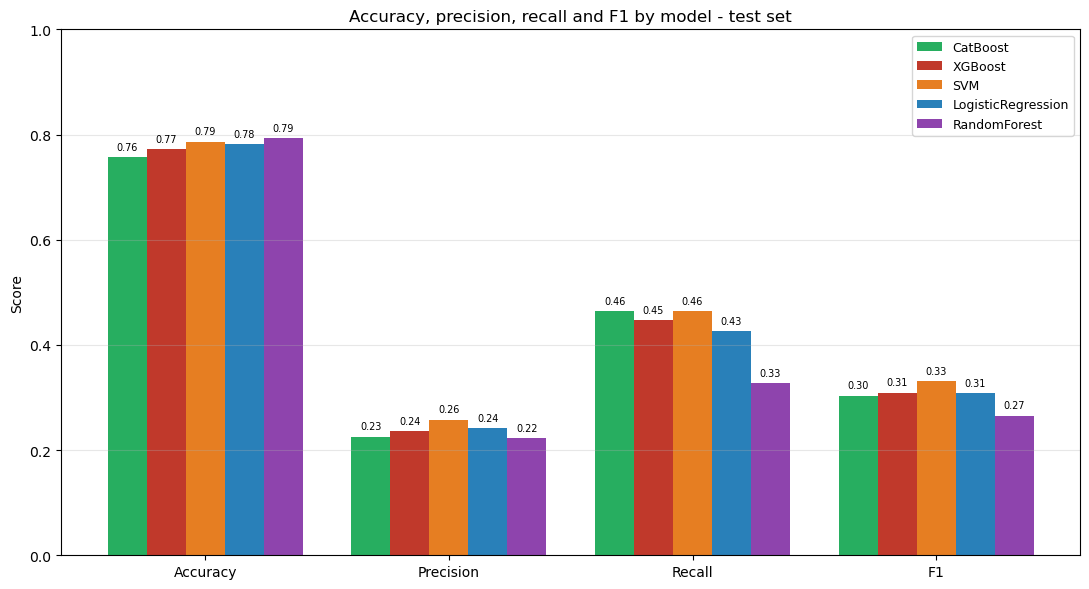

In [41]:
# Grouped bars for exactly the four metrics the project plan asked for
plot_frame = test_tuned.set_index("Model")[COURSE_METRICS]

x_positions = np.arange(len(COURSE_METRICS))
bar_width = 0.8 / len(plot_frame)

fig, ax = plt.subplots(figsize=(11, 6))

for index, (model_name, row) in enumerate(plot_frame.iterrows()):
    offset = (index - (len(plot_frame) - 1) / 2) * bar_width
    bars = ax.bar(x_positions + offset, row.values, bar_width,
                  label=model_name, color=MODEL_COLORS.get(model_name, "#7f8c8d"))

    # Print the value on top of each bar so the chart can be read without the table
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x_positions)
ax.set_xticklabels(COURSE_METRICS)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.0)
ax.set_title("Accuracy, precision, recall and F1 by model - test set")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "6_3_course_metrics_by_model.png"), dpi=150)
plt.show()

Notice that the accuracy bars are tall and nearly equal for every model, while recall varies a lot. That is the clearest picture of why accuracy cannot be the deciding metric on this dataset.

### Pick the Final Model

In [42]:
# Apply the selection rule to the test table and return the winner plus the reasoning
def select_final_model(test_table, tie_margin):
    if test_table.empty:
        raise ValueError("No test results to select from")

    ranked = test_table.sort_values("PR_AUC", ascending=False).reset_index(drop=True)
    leader = ranked.loc[0]
    reasons = [f"Highest test PR-AUC: {leader['Model']} at {leader['PR_AUC']:.4f}."]

    # Every model within the margin of the best PR-AUC counts as tied
    contenders = ranked[ranked["PR_AUC"] >= leader["PR_AUC"] - tie_margin]

    if len(contenders) == 1:
        reasons.append(
            f"No other model is within {tie_margin:.3f} PR-AUC, so the primary rule decides."
        )
        return leader["Model"], reasons

    reasons.append(
        f"Within {tie_margin:.3f} PR-AUC this is a tie between: {', '.join(contenders['Model'])}."
    )

    # Tie-break on recall, because a missed case costs more than a false alarm
    winner = contenders.sort_values("Recall", ascending=False).iloc[0]
    reasons.append(
        f"Tie-break on recall: {winner['Model']} recovers "
        f"{winner['Recall']:.4f} of true positive cases, the highest among the tied models."
    )

    return winner["Model"], reasons

In [43]:
# Run the rule
selected_name, selection_reasons = select_final_model(test_tuned, PR_AUC_TIE_MARGIN)

print("Selection reasoning")
print("-" * 60)
for step, reason in enumerate(selection_reasons, start=1):
    print(f"{step}. {reason}")

print()
print(f"FINAL MODEL: {selected_name}")

# Repeat the fairness warning here, where the decision is actually made
winner_audit = feature_audit.set_index("Model").loc[selected_name]
if winner_audit["Extra_Non_Standard"] != "-":
    print()
    print(f"WARNING  {selected_name} was trained on extra columns the other models dropped:")
    print(f"         {winner_audit['Extra_Non_Standard']}")
    print(f"         Treat this win as provisional until it is retrained on the same features.")

Selection reasoning
------------------------------------------------------------
1. Highest test PR-AUC: CatBoost at 0.2723.
2. Within 0.010 PR-AUC this is a tie between: CatBoost, XGBoost.
3. Tie-break on recall: CatBoost recovers 0.4638 of true positive cases, the highest among the tied models.

FINAL MODEL: CatBoost


In [44]:
# Pull the winning model and its test row back out for the detailed report
final_model = next(entry for entry in models if entry["name"] == selected_name)
final_row = test_tuned.set_index("Model").loc[selected_name]

print(f"{selected_name} - final test performance (threshold {final_model['threshold']:.4f})")
print()
print("  Metrics the project asked for")
for metric in COURSE_METRICS:
    print(f"    {metric:<10} {final_row[metric]:.4f}")

print()
print("  Supporting metrics")
for metric in ["PR_AUC", "ROC_AUC"]:
    print(f"    {metric:<10} {final_row[metric]:.4f}")

CatBoost - final test performance (threshold 0.5763)

  Metrics the project asked for
    Accuracy   0.7573
    Precision  0.2257
    Recall     0.4638
    F1         0.3036

  Supporting metrics
    PR_AUC     0.2723
    ROC_AUC    0.6761


#### Confusion matrix and classification report

In [45]:
# Rebuild the winner's test predictions at its tuned threshold
y_test = load_target("Test")
final_proba = probabilities[(selected_name, "Test")][1]
final_pred = (final_proba >= final_model["threshold"]).astype(int)

confusion = pd.DataFrame(
    confusion_matrix(y_test, final_pred),
    index=["Actual: No depression", "Actual: Depression"],
    columns=["Predicted: No", "Predicted: Yes"],
)

print(f"{selected_name} - test set confusion matrix "
      f"(threshold {final_model['threshold']:.3f})")
display(confusion)

print()
print(classification_report(
    y_test, final_pred,
    target_names=["No depression", "Depression"],
    digits=3,
))

CatBoost - test set confusion matrix (threshold 0.576)


,Predicted: No,Predicted: Yes
Actual: No depression,1451,374
Actual: Depression,126,109



               precision    recall  f1-score   support

No depression      0.920     0.795     0.853      1825
   Depression      0.226     0.464     0.304       235

     accuracy                          0.757      2060
    macro avg      0.573     0.629     0.578      2060
 weighted avg      0.841     0.757     0.790      2060



In [46]:
# Translate the four confusion matrix cells into plain counts for the write-up
true_negative, false_positive, false_negative, true_positive = confusion_matrix(
    y_test, final_pred
).ravel()

print(f"Out of {len(y_test)} people in the test set:")
print(f"  {true_positive} depressed people were correctly flagged (true positives)")
print(f"  {false_negative} depressed people were missed (false negatives)")
print(f"  {false_positive} non-depressed people were flagged by mistake (false positives)")
print(f"  {true_negative} non-depressed people were correctly cleared (true negatives)")
print()
print(f"The model finds {true_positive / (true_positive + false_negative):.1%} of depressed people.")
print(f"When it raises a flag, it is right {true_positive / (true_positive + false_positive):.1%} of the time.")

Out of 2060 people in the test set:
  109 depressed people were correctly flagged (true positives)
  126 depressed people were missed (false negatives)
  374 non-depressed people were flagged by mistake (false positives)
  1451 non-depressed people were correctly cleared (true negatives)

The model finds 46.4% of depressed people.
When it raises a flag, it is right 22.6% of the time.


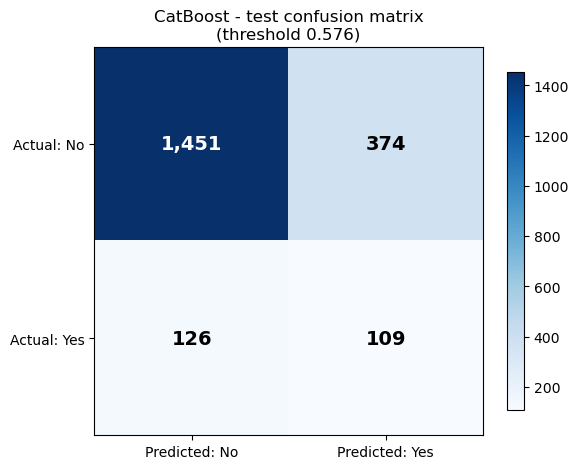

In [47]:
# Plot the confusion matrix so the report has a figure for it
fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(confusion.values, cmap="Blues")

ax.set_xticks([0, 1], labels=["Predicted: No", "Predicted: Yes"])
ax.set_yticks([0, 1], labels=["Actual: No", "Actual: Yes"])

# Write the count inside each cell, switching text color so it stays readable
for row in range(2):
    for column in range(2):
        value = confusion.values[row, column]
        text_color = "white" if value > confusion.values.max() / 2 else "black"
        ax.text(column, row, f"{value:,}", ha="center", va="center",
                color=text_color, fontsize=14, fontweight="bold")

ax.set_title(f"{selected_name} - test confusion matrix\n"
             f"(threshold {final_model['threshold']:.3f})")
fig.colorbar(image, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "6_4_final_confusion_matrix.png"), dpi=150)
plt.show()

### Save Results

Everything the written report needs, written to disk in one place.

In [48]:
# Write the one comparison table that the report should cite
results_sorted = results.sort_values(
    ["Split", "Threshold_Type", "PR_AUC"], ascending=[True, True, False]
).reset_index(drop=True)

results_sorted.to_csv(COMPARISON_CSV, index=False)
print(f"Saved comparison table: {COMPARISON_CSV}  ({len(results_sorted)} rows)")

Saved comparison table: .\Models\final_model_comparison.csv  (20 rows)


In [49]:
# Save the winning model together with everything needed to reuse it
joblib.dump(
    {
        "model": final_model["model"],
        "model_name": selected_name,
        "threshold": final_model["threshold"],
        "encoding_stem": final_model["stem"],
        "columns": final_model["columns"],
        "categorical": final_model["categorical"],
        "params": final_model["params"],
        "test_metrics": {
            metric: float(final_row[metric])
            for metric in COURSE_METRICS + ["PR_AUC", "ROC_AUC"]
        },
        "selection_rule": "Highest test PR-AUC, tie-break on recall",
        "random_state": RANDOM_STATE,
    },
    FINAL_MODEL_PATH,
)

print(f"Saved final model: {FINAL_MODEL_PATH}")

Saved final model: .\Models\final_model.joblib


In [50]:
# Build a plain text model card so the report and the reader agree on what was chosen
def build_model_card(name, entry, metrics_row, reasons, compared, audit_row, missing_predictors):
    import textwrap

    positive_rate = load_target("Test").mean()

    # Write each metric as an aligned name and value, no table markup
    def metric_lines(metric_names):
        return "\n".join(
            f"  {metric:<11} {metrics_row[metric]:.4f}" for metric in metric_names
        )

    # Wrap one long sentence into a bullet, keeping continuation lines indented
    def bullet(text):
        return textwrap.fill(text, width=76, initial_indent="  - ", subsequent_indent="    ")

    # Wrap plain prose with a simple indent and no bullet marker
    def paragraph(text):
        return textwrap.fill(text, width=76, initial_indent="  ", subsequent_indent="  ")

    # Wrap one numbered reason so long lines stay lined up under the number
    def numbered(position, text):
        return textwrap.fill(
            text, width=76,
            initial_indent=f"  {position}. ", subsequent_indent="     ",
        )

    reason_lines = "\n".join(
        numbered(position, reason) for position, reason in enumerate(reasons, start=1)
    )

    # Limits that always apply
    limits = [
        "PHQ9_Score and all raw PHQ-9 items were removed before modeling to prevent "
        "target leakage.",
        "The test set was scored once per model, at a threshold chosen on validation only.",
        "This is a screening aid built on self-reported survey data. It does not "
        "diagnose depression.",
    ]

    # Add the fairness note only if this model used columns the others dropped
    if audit_row["Extra_Non_Standard"] != "-":
        limits.append(
            f"FAIRNESS CAVEAT: this model was trained on "
            f"{audit_row['Extra_Non_Standard']}, which the other models dropped. "
            f"Its win is provisional until it is retrained on the same feature set."
        )

    # Add the coverage note only if some planned predictor never made it into the data
    if missing_predictors:
        limits.append(
            f"PLANNED PREDICTORS NOT AVAILABLE: {', '.join(missing_predictors)}. "
            f"These were named in the project plan but are not in the modeling files, "
            f"so no model could use them."
        )

    limit_lines = "\n".join(bullet(limit) for limit in limits)

    rank_note = (
        f"PR-AUC is used to rank because the target is imbalanced at about "
        f"{positive_rate:.1%} positive, which makes accuracy a poor ranking metric. "
        f"All four required metrics are reported above."
    )

    return f"""FINAL MODEL CARD
{"=" * 72}

SELECTED MODEL
  Model              {name}
  Threshold          {entry["threshold"]:.4f}  (tuned on validation, not on test)
  Feature encoding   {entry["stem"]}
  Features used      {len(entry["columns"])}
  Random seed        {RANDOM_STATE}

TEST SET PERFORMANCE - METRICS THE PROJECT ASKED FOR
{metric_lines(COURSE_METRICS)}

SUPPORTING METRICS
{metric_lines(["PR_AUC", "ROC_AUC"])}

SELECTION RULE
{paragraph(f"Primary is highest test PR-AUC. Tie-break is highest test recall when two models are within {PR_AUC_TIE_MARGIN:.3f} PR-AUC of each other.")}

{reason_lines}

{paragraph(rank_note)}

MODELS COMPARED
{paragraph(", ".join(compared))}

NOTES AND LIMITS
{limit_lines}
"""


card_text = build_model_card(
    selected_name,
    final_model,
    final_row,
    selection_reasons,
    [entry["name"] for entry in models],
    feature_audit.set_index("Model").loc[selected_name],
    not_in_data,
)

with open(MODEL_CARD_PATH, "w", encoding="utf-8") as handle:
    handle.write(card_text)

print(f"Saved model card: {MODEL_CARD_PATH}")
print()
print(card_text)

Saved model card: .\Models\final_model_card.md

FINAL MODEL CARD

SELECTED MODEL
  Model              CatBoost
  Threshold          0.5763  (tuned on validation, not on test)
  Feature encoding   Nhanes_Cat
  Features used      18
  Random seed        42

TEST SET PERFORMANCE - METRICS THE PROJECT ASKED FOR
  Accuracy    0.7573
  Precision   0.2257
  Recall      0.4638
  F1          0.3036

SUPPORTING METRICS
  PR_AUC      0.2723
  ROC_AUC     0.6761

SELECTION RULE
  Primary is highest test PR-AUC. Tie-break is highest test recall when two
  models are within 0.010 PR-AUC of each other.

  1. Highest test PR-AUC: CatBoost at 0.2723.
  2. Within 0.010 PR-AUC this is a tie between: CatBoost, XGBoost.
  3. Tie-break on recall: CatBoost recovers 0.4638 of true positive cases,
     the highest among the tied models.

  PR-AUC is used to rank because the target is imbalanced at about 11.4%
  positive, which makes accuracy a poor ranking metric. All four required
  metrics are reported above

### Summary and Next Steps

- The models finish close together. With a test set this size, a PR-AUC gap of a few thousandths is inside the noise. Say the top models perform *comparably* rather than claiming one is clearly better.
- Every model sits well above the no-skill baseline but precision stays low. That is expected when predicting a rare outcome from general survey features, and it is the honest finding, not a failure.
- The threshold is a policy choice, not a fact. A screening program that can absorb more follow-ups would lower it to catch more cases.
- The target is a PHQ-9 screening cut-off, not a clinical diagnosis. Say "screens positive for depression", not "is depressed".

**What we can do further imporvement in future**

- Bootstrap 95% confidence intervals on test PR-AUC to show whether the gap between the top two models is real.
- Add a calibration curve and Brier score if the predicted probability itself needs to be trusted, not just the ranking.
- Compare the top features across models. Features that all of them agree on are the most defensible story for the report.